In [59]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
os.chdir('..')

In [60]:
def findWaveFronts(frame,
                   k=5):
    scale = 1
    delta = 0
    ddepth = cv.CV_16S
    og_shape = frame.shape

    grad_x = cv.Sobel(frame, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv.BORDER_DEFAULT)
    # Gradient-Y
    # grad_y = cv.Scharr(gray,ddepth,0,1)
    grad_y = cv.Sobel(frame, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv.BORDER_DEFAULT)
        
        
    abs_grad_x = cv.convertScaleAbs(grad_x)
    abs_grad_y = cv.convertScaleAbs(grad_y)
        
        
    grad = cv.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)
    grad_flat = grad.flatten()
    best_indices = np.argsort(grad_flat)[-k:]
    points = [np.unravel_index(idx,og_shape) for idx in best_indices]
    points = np.asarray(points)[:,[1, 0]]
    return points[:, np.newaxis, :]

In [61]:
def findWavePeaks(frame,
                   k=5):
    og_shape = frame.shape
    frame_flat = frame.flatten()
    best_indices = np.argsort(frame_flat)[-k:]
    points = [np.unravel_index(idx,og_shape) for idx in best_indices]
    points = np.asarray(points)[:,[1, 0]]
    return points[:, np.newaxis, :]

In [ ]:
wave_type = "travelling"
dir_path = f"/home/theniche/School/REU25/WavesExcitability/Code/frames_{wave_type}"

In [63]:
from directory_tools import *
vid_frames = getFramesInOrder(dir_path)

In [64]:
vid_frames = vid_frames[20:]


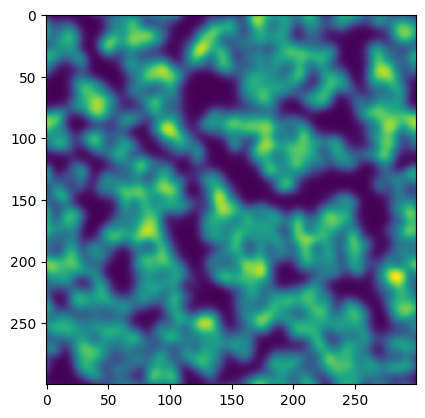

In [65]:
plt.imshow(vid_frames[0])

In [66]:
vid_frames = np.asarray(vid_frames)

In [67]:
max_conc = np.max(vid_frames)
min_conc = np.min(vid_frames)
def transform_to_int(array, min, max):
    res = np.asarray((array - min)/max * 255, dtype=np.uint8)
    return res

In [68]:
img_frames = transform_to_int(vid_frames, min_conc, max_conc)

In [69]:
def save_vid(img_frames, 
            output_path =f'output_{wave_type}.mp4',
            fps = 10,
            frame_size = vid_frames[0].shape,
            is_color = False):
    fourcc = cv.VideoWriter_fourcc(*'mp4v')
    video_writer = cv.VideoWriter(output_path, fourcc, fps, frame_size, is_color)

    for frame in img_frames:
        video_writer.write(frame)

    video_writer.release() 

In [70]:
save_vid(img_frames)

In [71]:
vid = cv.VideoCapture(f"/home/theniche/School/REU25/WavesExcitability/Code/output_{wave_type}.mp4")

In [72]:

# params for ShiTomasi corner detection
feature_params = dict( maxCorners = 100,
                       qualityLevel = 0.1,
                       minDistance = 7,
                       blockSize = 4 )

In [73]:

# Parameters for lucas kanade optical flow
lk_params = dict( winSize  = (10, 10),
                  maxLevel = 1,
                  criteria = (cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.03))

In [74]:
# Create some random colors
color = np.random.randint(0, 255, (100, 3))

In [75]:
# Take first frame and find corners in it
ret, old_frame = vid.read()
old_gray = cv.cvtColor(old_frame, cv.COLOR_BGR2GRAY)
#p0 = cv.goodFeaturesToTrack(old_gray, mask = None, **feature_params)
p0= findWaveFronts(old_gray, k=10).astype(np.float32)
#p0 = findWavePeaks(old_gray, k=10).astype(np.float32)

In [76]:
print(p0[:,0,:])

[[ 32.  80.]
 [100.  40.]
 [119.  26.]
 [ 99.  39.]
 [120.  23.]
 [ 47.  20.]
 [119.  27.]
 [ 47.  19.]
 [119.  23.]
 [119.  24.]]


Text(0.5, 1.0, 'STANDING')

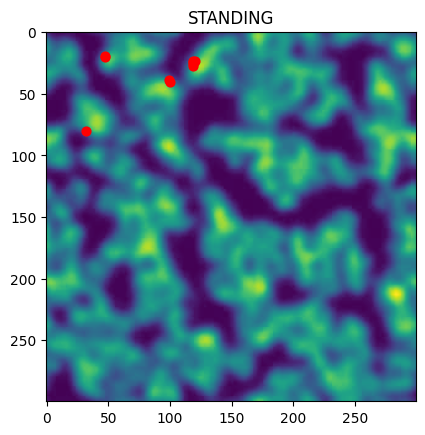

In [77]:
plt.imshow(old_gray)
plt.scatter(p0[:,0,0],p0[:,0,1], color='red', s=40)
plt.title(f'{wave_type.upper()}')

In [78]:
# Create a mask image for drawing purposes
new_frames = []
final_points = {(point[0],point[1]) : (point[0], point[1]) for point in p0[:,0, :]}
final_times = {(point[0],point[1]): 0 for point in p0[:,0, :]}
mask = np.zeros_like(old_frame)
frame_num = 0
while(1):
    frame_num = frame_num + 1
    ret, frame = vid.read()
    if not ret:
        print('No frames grabbed!')
        break
    frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    print(p0)
    # calculate optical flow
    p1, st, err = cv.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    print(f'{st=}')
    # Select good points
    if p1 is not None:
        good_new = p1[st==1]
        good_old = p0[st==1]
    # draw the tracksstanding
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        for key, value in final_points.items():
            if value == (c, d):
                final_points[key] = (a,b)
                final_times[key] = frame_num
        mask = cv.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
        frame = cv.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
    img = cv.add(frame, mask)


    cv.imshow('frame', img)
    k = cv.waitKey(30) & 0xff
    if k == 27:
        break

    new_frames.append(img)
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

cv.destroyAllWindows()


[[[ 32.  80.]]

 [[100.  40.]]

 [[119.  26.]]

 [[ 99.  39.]]

 [[120.  23.]]

 [[ 47.  20.]]

 [[119.  27.]]

 [[ 47.  19.]]

 [[119.  23.]]

 [[119.  24.]]]
st=array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1]], dtype=uint8)
[[[ 97.125984   141.56287   ]]

 [[ 42.78637     -1.5484676 ]]

 [[139.37471      4.513369  ]]

 [[ 94.81828     39.321884  ]]

 [[118.63477     30.907942  ]]

 [[ 46.371918    -3.0350723 ]]

 [[142.70192     -0.40429974]]

 [[ 44.53362     -1.976397  ]]

 [[119.33076     27.062334  ]]

 [[124.32598     25.959452  ]]]
st=array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1]], dtype=uint8)
[[[ 95.38385  139.22507 ]]

 [[ 50.55973   18.906418]]

 [[142.2262    35.717983]]

 [[117.130684  66.02443 ]]

 [[109.7231    24.392048]]

 [[ 85.216606  19.436335]]

 [[117.860695  64.19931 ]]

 [[ 52.148384  19.079407]]

 [[135.61502   36.4109

In [79]:
final_points

{(np.float32(32.0), np.float32(80.0)): (np.float32(258.9687),
  np.float32(84.60955)),
 (np.float32(100.0), np.float32(40.0)): (np.float32(12.145942),
  np.float32(3.9690313)),
 (np.float32(119.0), np.float32(26.0)): (np.float32(64.20624),
  np.float32(4.8530474)),
 (np.float32(99.0), np.float32(39.0)): (np.float32(171.24089),
  np.float32(3.0390837)),
 (np.float32(120.0), np.float32(23.0)): (np.float32(56.23034),
  np.float32(238.36285)),
 (np.float32(47.0), np.float32(20.0)): (np.float32(97.26555),
  np.float32(0.1311529)),
 (np.float32(119.0), np.float32(27.0)): (np.float32(118.650604),
  np.float32(-2.3184834)),
 (np.float32(47.0), np.float32(19.0)): (np.float32(3.5746183),
  np.float32(15.466623)),
 (np.float32(119.0), np.float32(23.0)): (np.float32(122.47509),
  np.float32(34.916306)),
 (np.float32(119.0), np.float32(24.0)): (np.float32(136.6199),
  np.float32(203.98463))}

In [80]:
lengths = []
velocities = []
for key, value in final_points.items():
    dist = np.sqrt((value[1] - key[1])**2 + (value[0] - key[0])**2)
    time = final_times[key]
    lengths.append(dist)
    if time != 0:
        velocities.append(dist/time)
    else:
        velocities.append(0.0)
print(np.median(lengths))
print(np.median(velocities))


69.714714
5.014458


In [81]:
print(np.asarray(lengths))

[227.01549   94.955605  58.732872  80.696556 224.60573   54.049946
  29.320566  43.568893  12.412679 180.84505 ]


In [82]:
print(np.asarray(velocities))

[ 9.870238  15.825934   4.195205   1.9682087  3.8068767 13.512486
  4.1886525 10.892223   2.0687797  5.833711 ]


In [83]:
len(new_frames)

79

In [84]:
save_vid([old_frame] + new_frames, output_path=f'optical_flow_{wave_type}.mp4', fps=3, frame_size=img_frames[0].shape, is_color=True)

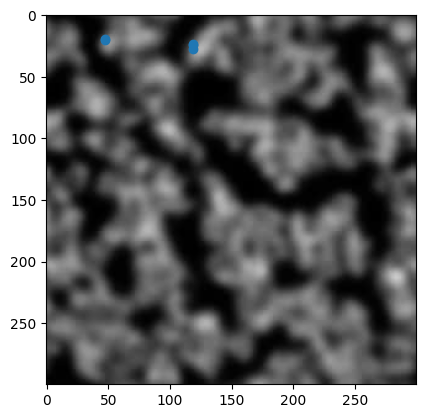

In [85]:
old_gray = cv.cvtColor(old_frame, cv.COLOR_BGR2GRAY)
p0= findWaveFronts(old_gray, k=5).astype(np.float32)
plt.imshow(old_frame)
plt.scatter(p0[:,0,0],p0[:,0,1])

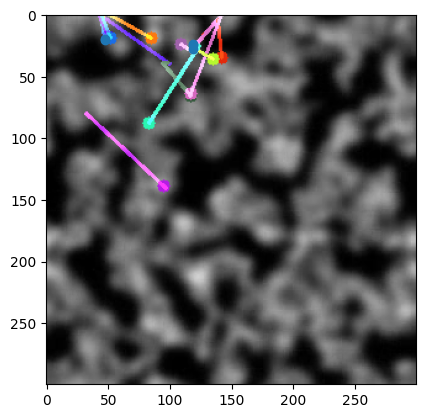

In [86]:
plt.imshow(new_frames[1])
plt.scatter(p0[:,0,0],p0[:,0,1])

In [87]:
[img_frames[0]] + new_frames

[array([[23, 19, 15, ..., 39, 34, 28],
        [30, 25, 20, ..., 47, 42, 36],
        [39, 33, 27, ..., 57, 51, 45],
        ...,
        [11,  9,  7, ..., 23, 19, 15],
        [14, 11,  8, ..., 27, 22, 18],
        [18, 14, 11, ..., 32, 27, 22]], shape=(300, 300), dtype=uint8),
 array([[[46, 46, 46],
         [45, 45, 45],
         [47, 47, 47],
         ...,
         [46, 46, 46],
         [43, 43, 43],
         [40, 40, 40]],
 
        [[52, 52, 52],
         [51, 51, 51],
         [53, 53, 53],
         ...,
         [54, 54, 54],
         [51, 51, 51],
         [48, 48, 48]],
 
        [[58, 58, 58],
         [57, 57, 57],
         [58, 58, 58],
         ...,
         [61, 61, 61],
         [58, 58, 58],
         [57, 57, 57]],
 
        ...,
 
        [[24, 24, 24],
         [24, 24, 24],
         [23, 23, 23],
         ...,
         [33, 33, 33],
         [29, 29, 29],
         [30, 30, 30]],
 
        [[32, 32, 32],
         [31, 31, 31],
         [31, 31, 31],
         ...,
  